### 1. Libraries & Function


In [2]:
import os
import warnings
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from oemof.solph import (Bus, EnergySystem, Flow, Model, create_time_index, processing)
from oemof.solph.components import (Sink, Source, Converter, GenericStorage)
from oemof.solph import EnergySystem
from oemof.solph import views
import oemof.solph as solph


def LCOH(invest_cost, operation_cost, heat_produced, revenue=0, i=0.05, n=20):
    pvf = ((1 + i) ** n - 1) / ((1 + i) ** n * i)
    return (invest_cost + pvf * (operation_cost - revenue)) / (
        pvf * heat_produced
    )
def epc(invest_cost, i=0.05, n=20):
    af = (i * (1 + i) ** n) / ((1 + i) ** n - 1)
    return invest_cost * af

filename = r"OEMOF_files/input_data.csv"
data = pd.read_csv(filename)
solver = "cbc"
solver_verbose = False

print(data.columns.tolist())

['thermal_demand_MW', 'electricity_price_Euro_Per_MWh', 'co2_price', 'gas_price_Euro_Per_MWh', 'biomass_Euro_Per_MWh', 'waste_Euro_Per_MWh', 'irradiance_direct_MW/m2', 'irradiance_diffuse_MW/m2']


### 2. Energy System

In [3]:
capacity_gas_heat       = 5         # MW
capacity_biomass_chp    = 15        # MW
capacity_wte_chp        = 7        # MW
max_heat_hp             = 3         # MW
area_m2                 = 20000     # m2



datetimeindex = create_time_index(2023, number=len(data)) 
energysystem = EnergySystem(timeindex=datetimeindex, infer_last_interval=False)

electrical_bus = Bus(label="electrical_bus") # Electricity bus
thermal_bus = Bus(label="thermal_bus") # Heat bus
gas_bus = Bus(label="gas_bus") # Natural gas bus
biomass_bus = Bus(label="biomass_bus") # Biomass bus
waste_bus = Bus(label="waste_bus") # Municipal Waste bus
wasteheat_bus = Bus(label="wasteheat_bus") # Waste Heat bus
energysystem.add(electrical_bus, thermal_bus, gas_bus, biomass_bus, waste_bus, wasteheat_bus)

#============================== SOURCES =============================#
energysystem.add(
    Source(label="natural_gas",outputs={gas_bus: Flow(variable_costs=data["gas_price_Euro_Per_MWh"])})
                )
energysystem.add(
    Source(label="electricity_grid",outputs={electrical_bus: Flow(variable_costs=data["electricity_price_Euro_Per_MWh"])})
                )
energysystem.add(
    Source(label="biomass",outputs={biomass_bus: Flow(variable_costs=data["biomass_Euro_Per_MWh"])})
                )
energysystem.add(
    Source(label="waste",outputs={waste_bus: Flow(variable_costs=data["waste_Euro_Per_MWh"])})
                )
energysystem.add(
    Source(label="waste_heat",outputs={wasteheat_bus: Flow(variable_costs=0, nominal_value=0.5, max=1.0)})
                )

#============================== LOAD =============================#
thermal_peak = data["thermal_demand_MW"].max()
energysystem.add(
    Sink(
        label="thermal_demand",
        inputs={thermal_bus: Flow(
            nominal_value=thermal_peak,
            fix=data["thermal_demand_MW"] / thermal_peak
        )},
    )
)
energysystem.add(
    Sink(
        label="excess_electricity",
        inputs={electrical_bus: Flow(variable_costs=data["electricity_price_Euro_Per_MWh"] * -1)}
    )
)
#============================== CONVERTERS =============================#
# 1. Natural Gas DH Only Prod Unit

efficiency_gas_heat = 0.93
energysystem.add(
    Converter(
        label='heat_gas',
            inputs={gas_bus: Flow()},
            outputs={thermal_bus: Flow(nominal_value=capacity_gas_heat)},
            conversion_factors={  thermal_bus: efficiency_gas_heat,
                                    gas_bus: 1}
    )
)
# 2. Biomass Combined Heat and Power (CHP) units

efficiency_biomass_chp_elc = 0.14
efficiency_biomass_chp_th = 0.97
energysystem.add(
    Converter(
        label='chp_biomass',
            inputs={biomass_bus: Flow()},
            outputs={   electrical_bus: Flow(nominal_value=capacity_biomass_chp * efficiency_biomass_chp_elc),
                        thermal_bus: Flow(nominal_value=capacity_biomass_chp * efficiency_biomass_chp_th)},
            conversion_factors={    electrical_bus: 1, thermal_bus: 1,
                                    biomass_bus: 1}
    )
)

#3. Waste to Energy Plant

efficiency_wte_chp_elc = 0.22
efficiency_wte_chp_th = 0.80
wte_to_elc = efficiency_wte_chp_elc/(efficiency_wte_chp_th + efficiency_wte_chp_elc)
wte_to_th = efficiency_wte_chp_th/(efficiency_wte_chp_th + efficiency_wte_chp_elc)
energysystem.add(
    Converter(
        label='waste_to_energy',
            inputs={waste_bus: Flow()},
            outputs={   electrical_bus: Flow(nominal_value=capacity_wte_chp * wte_to_elc),
                        thermal_bus: Flow(nominal_value=capacity_wte_chp * wte_to_th)},
            conversion_factors={    electrical_bus: efficiency_wte_chp_elc, thermal_bus: efficiency_wte_chp_th,
                                    waste_bus: 1}
    )
)

# 4. Heat Pump
cop_hp = 3.5

energysystem.add(
    Converter(
        label="heat_pump",
        inputs={
            electrical_bus: Flow(),      # electricity input
            wasteheat_bus: Flow(),       # low-temperature / source heat
        },
        outputs={
            thermal_bus: Flow(nominal_value=max_heat_hp),  # max thermal capacity [MW]
        },
        conversion_factors={
            # electrical input: 1 / COP
            electrical_bus: 1 / cop_hp,
            # heat source input: (COP - 1) / COP
            wasteheat_bus: (cop_hp - 1) / cop_hp,
        },
    )
)


# 5. Solar Thermal Plant

tilt_deg = 45               # collector tilt (simple assumption)
eta = 0.48                  # annual efficiency = output/input = 0.5/1.05
annual_input = 1.05         # MWh_i per m2 per year
pump_fraction = 0.01        # 1% parasitic load
dni = data["irradiance_direct_MW/m2"].clip(lower=0)
dhi = data["irradiance_diffuse_MW/m2"].clip(lower=0)
cosZ = 0.3                  # simple average factor for Sweden
ghi = dhi + dni * cosZ
tilt = np.deg2rad(tilt_deg)
Rb = 1.0  # simple assumption (no tracking angles)
G_tilt = (
    dni * Rb +                       # beam on tilt
    dhi * (1 + np.cos(tilt)) / 2 +   # diffuse on tilt
    ghi * 0.2 * (1 - np.cos(tilt)) / 2   # ground reflection (albedo = 0.2)
)

G_tilt = G_tilt.clip(lower=0)
G_MWh = G_tilt / 1e6   # because 1 W = 1 Wh per hour
scale = annual_input / G_MWh.sum()
G_input = G_MWh * scale       # MWh_i/m2/h (scaled)
G_output = G_input * eta      # MWh_h/m2/h
solar_thermal_MW = G_output * area_m2  # MWh/h ≈ MW
pump_MW = pump_fraction * solar_thermal_MW
print("Solar thermal peak (MW):", solar_thermal_MW.max())
print("Annual thermal output (MWh):", solar_thermal_MW.sum())

Q_nominal = solar_thermal_MW.max()
solar_profile_pu = solar_thermal_MW / Q_nominal

energysystem.add(
    Source(
        label="solar_thermal",
        outputs={
            thermal_bus: Flow(
                nominal_value=Q_nominal,
                max=solar_profile_pu.values,
            )
        }
    )
)

#============================== OPTIMIZE =============================#
model = Model(energysystem,name="District Heating Optimization Model")
logging.info("Solving the optimization problem.")
model.solve(
    solver='cbc',
    solve_kwargs={"tee": True},
    cmdline_options={"ratioGap": "0.02"}
)

energysystem.results["main"] = processing.results(model)
energysystem.results["meta"] = processing.meta_results(model)
output_file = os.path.join(os.getcwd(), "Outputs/results.oemof")
energysystem.dump(os.getcwd(), "Outputs/results.oemof")
logging.info("Results have been dumped.")
results = energysystem.results["main"]

electrical_bus_view = views.node(results, "electrical_bus")
thermal_bus_view    = views.node(results, "thermal_bus")
gas_bus_view        = views.node(results, "gas_bus")
biomass_bus_view    = views.node(results, "biomass_bus")
# print(thermal_bus_view)

Solar thermal peak (MW): 8.43838564934685
Annual thermal output (MWh): 10079.999999999998
ERROR: Constructing component 'ConverterBlock.relation_build' from data=None
failed:
        KeyboardInterrupt:


KeyboardInterrupt: 

In [29]:
print(thermal_bus_view)

{'sequences':                      ((chp_biomass, thermal_bus), flow)  \
2023-01-01 00:00:00                                 2.1   
2023-01-01 01:00:00                                 2.1   
2023-01-01 02:00:00                                 2.1   
2023-01-01 03:00:00                                 2.1   
2023-01-01 04:00:00                                 2.1   
...                                                 ...   
2023-12-31 20:00:00                                 2.1   
2023-12-31 21:00:00                                 2.1   
2023-12-31 22:00:00                                 2.1   
2023-12-31 23:00:00                                -0.0   
2024-01-01 00:00:00                                 NaN   

                     ((heat_gas, thermal_bus), flow)  \
2023-01-01 00:00:00                              0.0   
2023-01-01 01:00:00                              0.0   
2023-01-01 02:00:00                              0.0   
2023-01-01 03:00:00                              0.0 

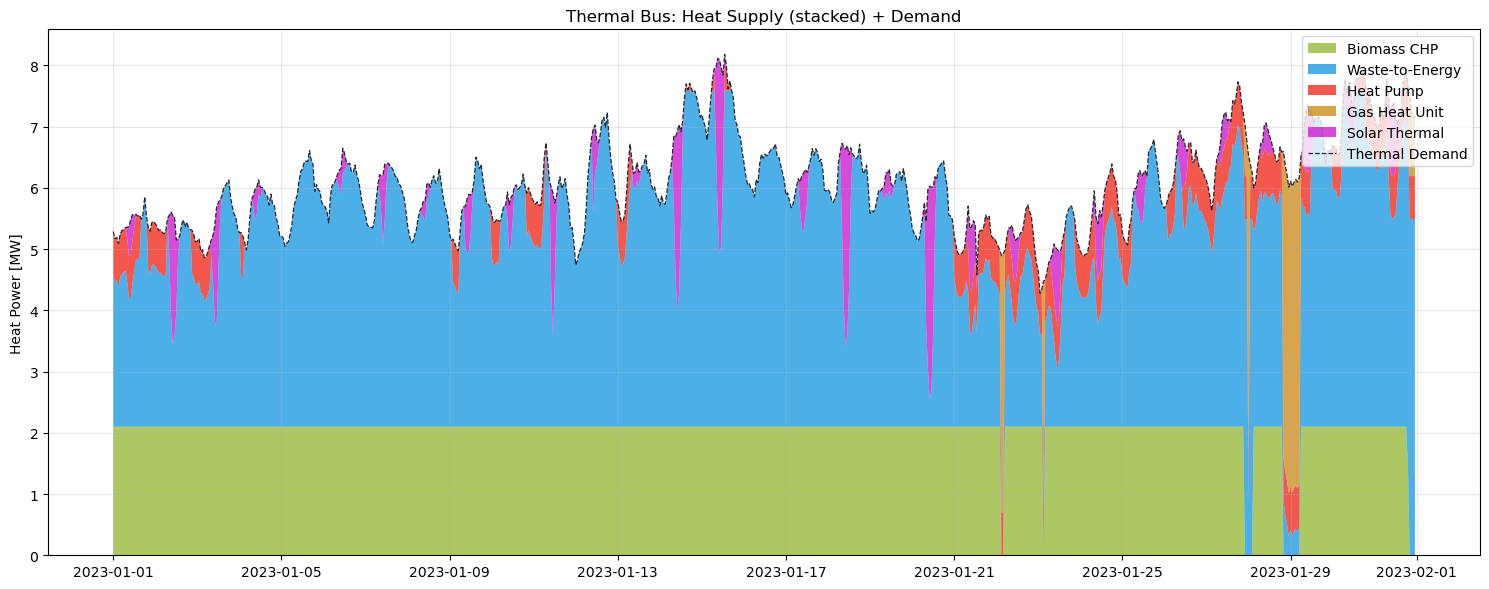

In [30]:
import matplotlib.pyplot as plt
from oemof.solph import views



thermal_bus_view = views.node(results, "thermal_bus")
seq = thermal_bus_view["sequences"].iloc[:-1]  

start = "2023-01-01"
end   = "2023-01-31"

seq = seq.loc[start:end]

# Column names from your results
col_wte       = (("waste_to_energy", "thermal_bus"), "flow")
col_biomass   = (("chp_biomass", "thermal_bus"), "flow")
col_gas       = (("heat_gas", "thermal_bus"), "flow")
col_hp        = (("heat_pump", "thermal_bus"), "flow")
col_solar_th  = (("solar_thermal", "thermal_bus"), "flow")  

has_hp = col_hp in seq.columns
has_solar_th = col_solar_th in seq.columns

# Desired order from BOTTOM (first) → TOP (last)
stack_order = [
    "biomass",
    "wte",    "hp",

    "gas",    "solar_th",

]
components = {
    "biomass": {
        "series": seq[col_biomass],
        "label": "Biomass CHP",
        "color": "#8AB020",
    },
    "gas": {
        "series": seq[col_gas],
        "label": "Gas Heat Unit",
        "color": "#C87E00",
    },
    "wte": {
        "series": seq[col_wte],
        "label": "Waste-to-Energy",
        "color": "#008DDF",
    },
    "hp": {
        "series": seq[col_hp] if has_hp else None,
        "label": "Heat Pump",
        "color": "#F01000",
    },
    "solar_th": {
        "series": seq[col_solar_th] if has_solar_th else None,
        "label": "Solar Thermal",
        "color": "#C500C8",
    },
}
supply_components = []
labels = []
colors = []

for key in stack_order:
    c = components[key]
    if c["series"] is not None:
        supply_components.append(c["series"])
        labels.append(c["label"])
        colors.append(c["color"])
plt.figure(figsize=(15, 6))

plt.stackplot(
    seq.index,
    *supply_components,
    labels=labels,
    colors=colors,
    alpha=0.7,
)

plt.plot(
    seq.index,
    seq[(("thermal_bus","thermal_demand"), "flow")],
    label="Thermal Demand",
    color="#262630",
    linestyle="--",
    linewidth=0.9,
)

plt.title("Thermal Bus: Heat Supply (stacked) + Demand")
plt.ylabel("Heat Power [MW]")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()



C:\Users\ardia\AppData\Local\Temp\ipykernel_10188\4015301243.py:26: FutureWarning: 'Y' is deprecated and will be removed in a future version, please use 'YE' instead.
  annual_sum = seq[col].resample('Y').sum().iloc[0]  # first year only (adjust if multi-year)


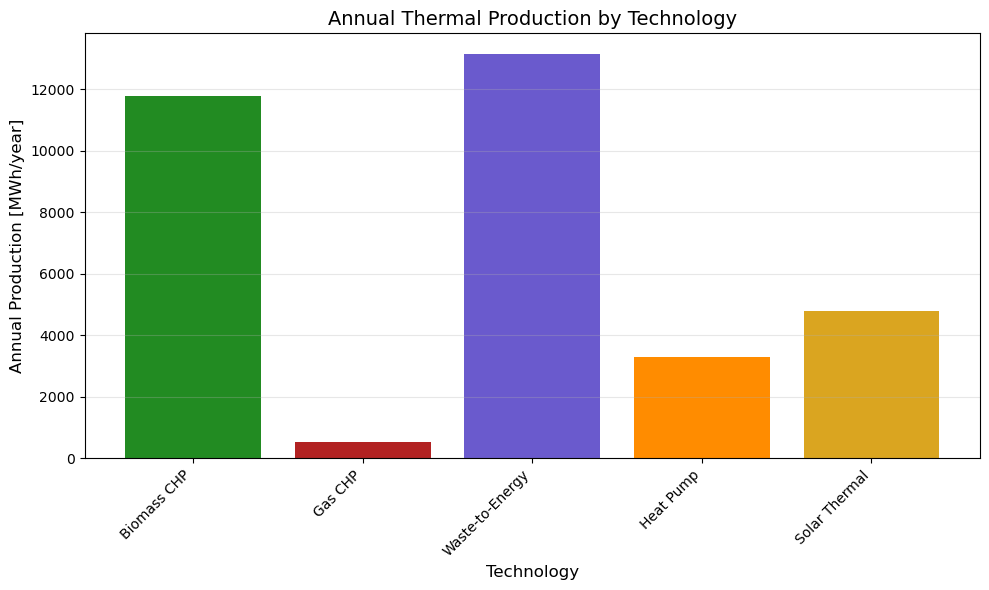

In [31]:
import matplotlib.pyplot as plt
import pandas as pd
from oemof.solph import views

# Extract sequences
thermal_bus_view = views.node(results, "thermal_bus")
seq = thermal_bus_view["sequences"].iloc[:-1]  # drop last NaN row

# Ensure datetime index
if not isinstance(seq.index, pd.DatetimeIndex):
    seq.index = pd.to_datetime(seq.index)

# Define the technology columns
tech_cols = {
    "Biomass CHP": (("chp_biomass", "thermal_bus"), "flow"),
    "Gas CHP":     (("heat_gas",     "thermal_bus"), "flow"),
    "Waste-to-Energy": (("waste_to_energy", "thermal_bus"), "flow"),
    "Heat Pump":   (("heat_pump",   "thermal_bus"), "flow"),
    "Solar Thermal": (("solar_thermal", "thermal_bus"), "flow")
}

# Aggregate annual production by technology
annual_yields = {}
for tech, col in tech_cols.items():
    if col in seq.columns:
        annual_sum = seq[col].resample('Y').sum().iloc[0]  # first year only (adjust if multi-year)
        annual_yields[tech] = annual_sum
    else:
        # Skip if technology not present
        annual_yields[tech] = 0.0

# Prepare for bar chart
technologies = list(annual_yields.keys())
values = [annual_yields[tech] for tech in technologies]

plt.figure(figsize=(10,6))
bars = plt.bar(technologies, values, color=['forestgreen','firebrick','slateblue','darkorange','goldenrod'])
plt.xlabel('Technology', fontsize=12)
plt.ylabel('Annual Production [MWh/year]', fontsize=12)
plt.title('Annual Thermal Production by Technology', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()


In [32]:
import pandas as pd
from pyomo.opt import TerminationCondition, SolverStatus

meta = energysystem.results["meta"]

print("\n==================== META RESULTS ====================\n")

# Objective
print(f"Objective value             : {float(meta['objective']):,.3f}")

# Problem information
problem = meta.get("problem", {})
print("\n--- Problem Structure ---")
print(f"Name                        : {problem.get('Name')}")
print(f"Constraints                 : {problem.get('Number of constraints'):,}")
print(f"Variables                   : {problem.get('Number of variables'):,}")
print(f"Nonzeros                    : {problem.get('Number of nonzeros'):,}")
print(f"Sense                       : {problem.get('Sense').name}")

# Solver information
solver = meta.get("solver", {})
print("\n--- Solver Information ---")
print(f"Status                      : {solver.get('Status').name}")
print(f"Termination condition       : {solver.get('Termination condition').name}")
print(f"Termination message         : {solver.get('Termination message')}")
print(f"User time (s)               : {solver.get('User time')}")
print(f"System time (s)             : {solver.get('System time')}")
print(f"Wallclock time (s)          : {solver.get('Wallclock time')}")
print(f"Reported Time (Pyomo) (s)   : {solver.get('Time')}")

print("\n======================================================\n")



==================== META RESULTS ====================

Objective value             : 65,450.213

--- Problem Structure ---
Name                        : unknown
Constraints                 : 113,880
Variables                   : 157,680
Nonzeros                    : 41,997
Sense                       : minimize

--- Solver Information ---
Status                      : ok
Termination condition       : optimal
Termination message         : Model was solved to optimality (subject to tolerances), and an optimal solution is available.
User time (s)               : -1.0
System time (s)             : 2.78
Wallclock time (s)          : 2.78
Reported Time (Pyomo) (s)   : 2.858647108078003




## NEW ATTEMPT


In [4]:
import os
import warnings
import logging
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from oemof.solph import (Bus, EnergySystem, Flow, Model, create_time_index, processing)
from oemof.solph.components import (Sink, Source, Converter, GenericStorage)
from oemof.solph import EnergySystem
from oemof.solph import views
import oemof.solph as solph


def LCOH(invest_cost, operation_cost, heat_produced, revenue=0, i=0.05, n=20):
    pvf = ((1 + i) ** n - 1) / ((1 + i) ** n * i)
    return (invest_cost + pvf * (operation_cost - revenue)) / (
        pvf * heat_produced
    )
def epc(invest_cost, i=0.05, n=20):
    af = (i * (1 + i) ** n) / ((1 + i) ** n - 1)
    return invest_cost * af

filename = r"OEMOF_files/input_data.csv"
data = pd.read_csv(filename)
solver = "cbc"
solver_verbose = False

print(data.columns.tolist())

capacity_gas_heat = 3         # MW
capacity_biomass_chp = 4        # MW
capacity_wte_chp = 4        # MW
max_heat_hp = 3         # MW
area_m2 = 4000     # m2


datetimeindex = create_time_index(2023, number=len(data))
energysystem = EnergySystem(timeindex=datetimeindex, infer_last_interval=False)

electrical_bus = Bus(label="electrical_bus")  # Electricity bus
thermal_bus = Bus(label="thermal_bus")  # Heat bus
gas_bus = Bus(label="gas_bus")  # Natural gas bus
biomass_bus = Bus(label="biomass_bus")  # Biomass bus
waste_bus = Bus(label="waste_bus")  # Municipal Waste bus
wasteheat_bus = Bus(label="wasteheat_bus")  # Waste Heat bus
energysystem.add(electrical_bus, thermal_bus, gas_bus,
                 biomass_bus, waste_bus, wasteheat_bus)

# ------------------------------------------------------------------
# SOURCES
# ------------------------------------------------------------------
energysystem.add(
    Source(
        label="natural_gas",
        outputs={gas_bus: Flow(variable_costs=data["gas_price_Euro_Per_MWh"])},
    )
)

energysystem.add(
    Source(
        label="electricity_grid",
        outputs={electrical_bus: Flow(variable_costs=data["electricity_price_Euro_Per_MWh"])},
    )
)

energysystem.add(
    Source(
        label="biomass",
        outputs={biomass_bus: Flow(variable_costs=data["biomass_Euro_Per_MWh"])},
    )
)

energysystem.add(
    Source(
        label="waste",
        outputs={waste_bus: Flow(variable_costs=data["waste_Euro_Per_MWh"])},
    )
)

energysystem.add(
    Source(
        label="waste_heat",
        outputs={wasteheat_bus: Flow(variable_costs=0, nominal_value=0.5, max=1.0)},
    )
)

# ------------------------------------------------------------------
# LOADS
# ------------------------------------------------------------------
thermal_peak = data["thermal_demand_MW"].max()

energysystem.add(
    Sink(
        label="thermal_demand",
        inputs={
            thermal_bus: Flow(
                nominal_value=thermal_peak,
                fix=data["thermal_demand_MW"] / thermal_peak,
            )
        },
    )
)

energysystem.add(
    Sink(
        label="excess_electricity",
        inputs={
            electrical_bus: Flow(
                variable_costs=data["electricity_price_Euro_Per_MWh"] * -1
            )
        },
    )
)

# ------------------------------------------------------------------
# CONVERTERS
# 1) Natural Gas DH Only Unit
# ------------------------------------------------------------------
efficiency_gas_heat = 0.93
startup_cost_gas = 8.0   # €/start
vom_heat = 0.64          # €/MWh_heat

energysystem.add(
    solph.components.Converter(
        label="heat_gas",
        inputs={gas_bus: solph.Flow()},
        outputs={
            thermal_bus: solph.Flow(
                nominal_value=capacity_gas_heat,
                min=0.1,
                variable_costs=vom_heat,   # O&M only
#                nonconvex=solph.NonConvex(
#                    startup_costs=startup_cost_gas,
#                    shutdown_costs=0,
#                    # minimum_uptime=1,
#                    # minimum_downtime=1,
#                    # initial_status=0,
#                ),
            )
        },
        conversion_factors={thermal_bus: efficiency_gas_heat},
    )
)

#from oemof import solph
from oemof.solph import Flow

# ------------------------------------------------------------------
#2. Biomass CHP parameters
# ------------------------------------------------------------------

# --- efficiencies from your datasheet ---
efficiency_biomass_chp_elc = 0.14        # net electric efficiency (CHP mode)
efficiency_biomass_chp_th_rel = 0.97     # "97% of remaining energy"
efficiency_biomass_chp_th = (
    1 - efficiency_biomass_chp_elc
) * efficiency_biomass_chp_th_rel        # ≈ 0.83 absolute heat efficiency

eta_el_cond_bio = 0.20   # assumed condensing electric efficiency (no heat)

# ---------- derive start-up / shutdown costs from your data ----------
eta_tot_biomass = efficiency_biomass_chp_elc + efficiency_biomass_chp_th  # ≈ 0.97
avg_biomass_price = float(data["biomass_Euro_Per_MWh"].mean())            # €/MWh_fuel

# fuel input at full CHP load (MW_fuel)
fuel_input_full = capacity_biomass_chp / eta_tot_biomass

# variable cost per hour at full load (€/h)
C_var_full = fuel_input_full * avg_biomass_price

# assume "equivalent hours" of variable cost per start
equiv_hours = 4.0
biomass_startup_cost = equiv_hours * C_var_full     # €/start
biomass_shutdown_cost = 0.2 * biomass_startup_cost  # €/shutdown

# you can use these also for a separate biomass boiler if needed
boiler_startup_cost  = biomass_startup_cost
boiler_shutdown_cost = biomass_shutdown_cost

# ---------- non-convex behaviour settings ----------
biomass_min_load     = 0.6    # ≥ 60% of fuel capacity when ON
biomass_min_uptime   = 96     # hours
biomass_min_downtime = 48     # hours

# ------------------------------------------------------------------
# Biomass CHP as ExtractionTurbineCHP
# ------------------------------------------------------------------

energysystem.add(
    solph.components.ExtractionTurbineCHP(
        label="chp_biomass",
        inputs={
            biomass_bus: Flow(
                nominal_value=capacity_biomass_chp,   # MW_fuel capacity
                min=biomass_min_load,                 # min load when ON
                nonconvex=solph.NonConvex(
                    startup_costs=biomass_startup_cost,
                    shutdown_costs=biomass_shutdown_cost,
                    minimum_uptime=biomass_min_uptime,
                    minimum_downtime=biomass_min_downtime,
                    initial_status=1,
                ),
            )
        },
        outputs={
            electrical_bus: Flow(),
            thermal_bus:    Flow(variable_costs=1.45), # €/MWh_th
        },
        # CHP-mode efficiencies (back-pressure / extraction region)
        conversion_factors={
            electrical_bus: efficiency_biomass_chp_elc,
            thermal_bus:    efficiency_biomass_chp_th,
        },
        # Condensing-mode electric efficiency (no heat)
        conversion_factor_full_condensation={
            electrical_bus: eta_el_cond_bio,
        },
    )
)

from oemof import solph
from oemof.solph import Flow

# ------------------------------------------------------------------
# Waste-to-Energy (WtE) CHP parameters
# ------------------------------------------------------------------

# --- efficiencies from your datasheet ---
efficiency_wte_chp_elc = 0.22          # net electric efficiency (CHP mode)
efficiency_wte_chp_th_rel = 0.80       # "80% of remaining energy"
efficiency_wte_chp_th = (
    1 - efficiency_wte_chp_elc
) * efficiency_wte_chp_th_rel          # ≈ 0.624 absolute heat efficiency

# assumed condensing electric efficiency (no heat)
eta_el_cond_wte = 0.26                 # tune if you have better data

# ---------- derive start-up / shutdown costs from your data ----------
# total CHP efficiency
eta_tot_wte = efficiency_wte_chp_elc + efficiency_wte_chp_th

# average fuel (waste) price in €/MWh_fuel
# NOTE: make sure this column exists in your data DataFrame
avg_wte_price = float(data["waste_Euro_Per_MWh"].mean())

# fuel input at full CHP load (MW_fuel)
fuel_input_full_wte = capacity_wte_chp / eta_tot_wte

# variable cost per hour at full load (€/h)
C_var_full_wte = fuel_input_full_wte * avg_wte_price

# assume "equivalent hours" of variable cost per start
equiv_hours_wte = 4.0
wte_startup_cost = equiv_hours_wte * C_var_full_wte      # €/start
wte_shutdown_cost = 0.2 * wte_startup_cost               # €/shutdown

# ---------- non-convex behaviour settings ----------
wte_min_load     = 0.5    # ≥ 50% of fuel capacity when ON
wte_min_uptime   = 48     # hours
wte_min_downtime = 24     # hours

# ------------------------------------------------------------------
# Waste-to-Energy CHP as ExtractionTurbineCHP
# ------------------------------------------------------------------

energysystem.add(
    solph.components.ExtractionTurbineCHP(
        label="waste_to_energy",
        inputs={
            waste_bus: Flow(
                nominal_value=capacity_wte_chp,    # MW_fuel capacity
                min=wte_min_load,                  # minimum load when ON
                nonconvex=solph.NonConvex(
                    startup_costs=wte_startup_cost,
                    shutdown_costs=wte_shutdown_cost,
                    minimum_uptime=wte_min_uptime,
                    minimum_downtime=wte_min_downtime,
                    initial_status=1,
                ),
            )
        },
        outputs={
            electrical_bus: Flow(),
            thermal_bus:    Flow(variable_costs=6.3),
        },
        # CHP-mode efficiencies (back-pressure / extraction region)
        conversion_factors={
            electrical_bus: efficiency_wte_chp_elc,
            thermal_bus:    efficiency_wte_chp_th,
        },
        # Condensing-mode electric efficiency (no heat)
        conversion_factor_full_condensation={
            electrical_bus: eta_el_cond_wte,
        },
    )
)


# ------------------------------------------------------------------
# 4) Heat Pump
# ------------------------------------------------------------------
cop_hp = 3.5

energysystem.add(
    solph.components.Converter(
        label="heat_pump",
        inputs={
            electrical_bus: Flow(),  # electricity input
            wasteheat_bus: Flow(),   # low-temperature/source heat
        },
        outputs={
            thermal_bus: Flow(nominal_value=max_heat_hp, variable_costs=2.86),  # max thermal capacity [MW]
        },
        conversion_factors={
            electrical_bus: 1 / cop_hp,              # electrical input
            wasteheat_bus: (cop_hp - 1) / cop_hp,    # source heat input
        },
    )
)

# ------------------------------------------------------------------
# 5) Solar Thermal Plant
# ------------------------------------------------------------------
tilt_deg = 45              # collector tilt
eta = 0.48                 # annual efficiency
annual_input = 1.05        # MWh_i per m2 per year
pump_fraction = 0.01       # 1% parasitic load

dni = data["irradiance_direct_MW/m2"].clip(lower=0)
dhi = data["irradiance_diffuse_MW/m2"].clip(lower=0)
cosZ = 0.3                 # simple average factor
ghi = dhi + dni * cosZ

tilt = np.deg2rad(tilt_deg)
Rb = 1.0                   # simple assumption (no tracking)

G_tilt = (
    dni * Rb +                                # beam on tilt
    dhi * (1 + np.cos(tilt)) / 2 +           # diffuse on tilt
    ghi * 0.2 * (1 - np.cos(tilt)) / 2       # ground reflection (albedo = 0.2)
)

G_tilt = G_tilt.clip(lower=0)
G_MWh = G_tilt / 1e6                          # W/m2 → MWh/m2 over 1h

scale = annual_input / G_MWh.sum()
G_input = G_MWh * scale                       # MWh_i/m2/h (scaled)
G_output = G_input * eta                      # MWh_th/m2/h

solar_thermal_MW = G_output * area_m2         # MWh/h ≈ MW
pump_MW = pump_fraction * solar_thermal_MW

print("Solar thermal peak (MW):", solar_thermal_MW.max())
print("Annual thermal output (MWh):", solar_thermal_MW.sum())

Q_nominal = solar_thermal_MW.max()
solar_profile_pu = solar_thermal_MW / Q_nominal

energysystem.add(
    Source(
        label="solar_thermal",
        outputs={
            thermal_bus: Flow(
                nominal_value=Q_nominal,
                max=solar_profile_pu.values,
            )
        },
    )
)

# ------------------------------------------------------------------
# HEAT STORAGE
# ------------------------------------------------------------------
storage_capacity_MWh = 80   # max stored heat [MWh]
max_charge_MW = 10          # max charging power [MW]
max_discharge_MW = 10       # max discharging power [MW]
loss_rate = 0.002           # fraction of energy lost per hour
initial_soc = 0.2           # 20% full at t=0
eff_charge = 0.98           # charging efficiency
eff_discharge = 0.98        # discharging efficiency

#energysystem.add(
#    GenericStorage(
#        label="heat_storage",
#        nominal_storage_capacity=80,
#        inputs={thermal_bus: Flow(nominal_value=10)},   # charge limit [kW]
#        outputs={thermal_bus: Flow(nominal_value=10)},  # discharge limit [kW]
#        loss_rate=0.001,
#        inflow_conversion_factor=1.0,
#        outflow_conversion_factor=0.99
#    )
#)

#energysystem.add(
#    GenericStorage(
#        label="heat_storage",
#        inputs={
#            thermal_bus: Flow(
#                nominal_value=max_charge_MW,
#                max=1.0,   # 0..1 * nominal_value
#            )
#        },
#        outputs={
#            thermal_bus: Flow(
#                nominal_value=max_discharge_MW,
#                max=1.0,   # 0..1 * nominal_value
#            )
#        },
#        nominal_storage_capacity=storage_capacity_MWh,
#        loss_rate=loss_rate,             # standing losses per timestep
#        initial_storage_level=initial_soc,  # relative (0..1)
#        inflow_conversion_factor=eff_charge,
#        outflow_conversion_factor=eff_discharge,
#        min_storage_level=0.2,
#        max_storage_level=0.8,
#    )
#)

# ------------------------------------------------------------------
# OPTIMIZE
# ------------------------------------------------------------------
model = Model(energysystem, name="District Heating Optimization Model")
logging.info("Solving the optimization problem.")

model.solve(
    solver="gurobi",
    solve_kwargs={"tee": True},
    #cmdline_options={"MIPGap": "0.1"},
),


energysystem.results["main"] = processing.results(model, remove_last_time_point=True)
#energysystem.results["main"] = processing.results(model)
energysystem.results["meta"] = processing.meta_results(model)

output_file = os.path.join(os.getcwd(), "Outputs/results.xlsx")
energysystem.dump(os.getcwd(), "Outputs/results.xlsx")
logging.info("Results have been dumped.")

results = energysystem.results["main"]

['thermal_demand_MW', 'electricity_price_Euro_Per_MWh', 'co2_price', 'gas_price_Euro_Per_MWh', 'biomass_Euro_Per_MWh', 'waste_Euro_Per_MWh', 'irradiance_direct_MW/m2', 'irradiance_diffuse_MW/m2']
Solar thermal peak (MW): 1.68767712986937
Annual thermal output (MWh): 2015.9999999999998
(type=<class 'pyomo.core.base.expression.ScalarExpression'>) on block
NonConvexFlowBlock with a new Component (type=<class
'pyomo.core.base.expression.ScalarExpression'>). This is usually indicative of
a modelling error. To avoid this warning, use block.del_component() and
block.add_component().
(type=<class 'pyomo.core.base.expression.ScalarExpression'>) on block
NonConvexFlowBlock with a new Component (type=<class
'pyomo.core.base.expression.ScalarExpression'>). This is usually indicative of
a modelling error. To avoid this warning, use block.del_component() and
block.add_component().
Set parameter Username
Set parameter LicenseID to value 2729760
Academic license - for non-commercial use only - expires

c:\Users\ardia\miniconda3\envs\env_P2\lib\site-packages\oemof\network\energy_system.py:256: FutureWarning: Parameter 'dpath' will be removed in a future version. You can give the directory as part of the filename and set 'consider_dpath' to False to suppress this waring.
  warnings.warn(


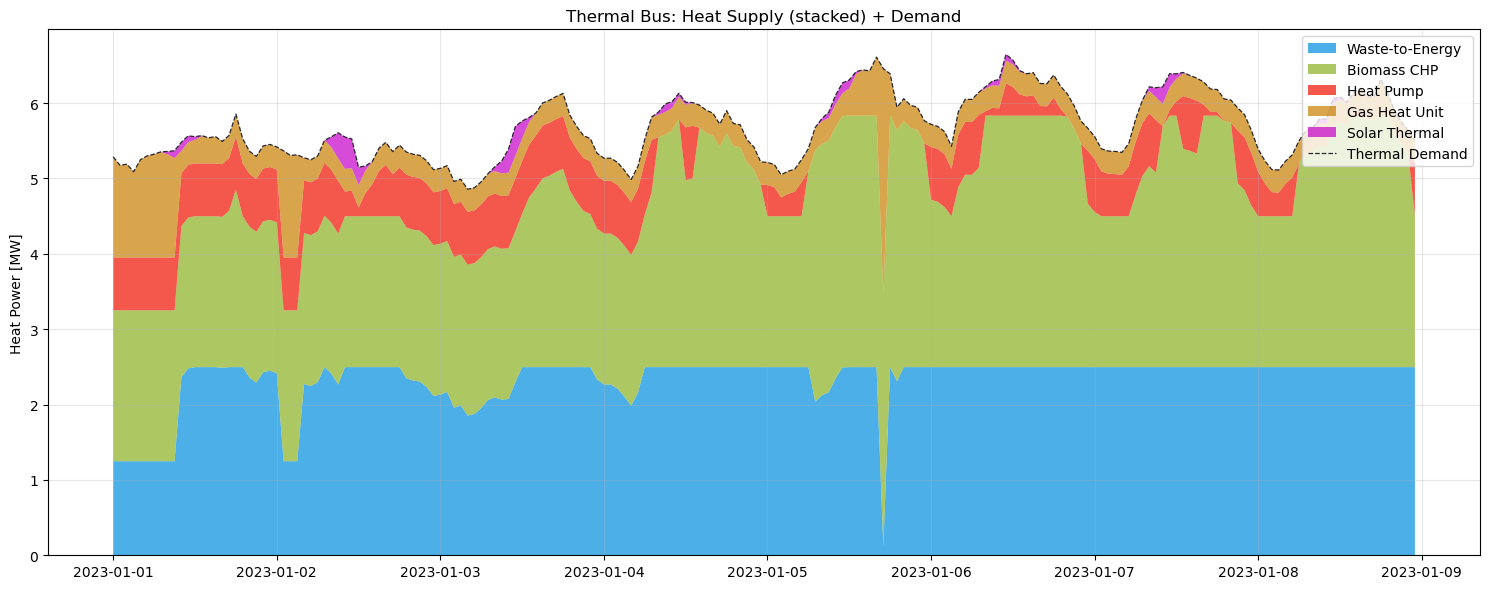

In [8]:
import matplotlib.pyplot as plt
from oemof.solph import views



thermal_bus_view = views.node(results, "thermal_bus")
seq = thermal_bus_view["sequences"].iloc[:-1]  

start = "2023-01-01"
end   = "2023-01-08"

seq = seq.loc[start:end]

# Column names from your results
col_wte       = (("waste_to_energy", "thermal_bus"), "flow")
col_biomass   = (("chp_biomass", "thermal_bus"), "flow")
col_gas       = (("heat_gas", "thermal_bus"), "flow")
col_hp        = (("heat_pump", "thermal_bus"), "flow")
col_solar_th  = (("solar_thermal", "thermal_bus"), "flow")  

has_hp = col_hp in seq.columns
has_solar_th = col_solar_th in seq.columns

# Desired order from BOTTOM (first) → TOP (last)
stack_order = [
    "wte",   
    "biomass",
    "hp", 

    "gas",    "solar_th",

]
components = {
    "biomass": {
        "series": seq[col_biomass],
        "label": "Biomass CHP",
        "color": "#8AB020",
    },
    "gas": {
        "series": seq[col_gas],
        "label": "Gas Heat Unit",
        "color": "#C87E00",
    },
    "wte": {
        "series": seq[col_wte],
        "label": "Waste-to-Energy",
        "color": "#008DDF",
    },
    "hp": {
        "series": seq[col_hp] if has_hp else None,
        "label": "Heat Pump",
        "color": "#F01000",
    },
    "solar_th": {
        "series": seq[col_solar_th] if has_solar_th else None,
        "label": "Solar Thermal",
        "color": "#C500C8",
    },
}
supply_components = []
labels = []
colors = []

for key in stack_order:
    c = components[key]
    if c["series"] is not None:
        supply_components.append(c["series"])
        labels.append(c["label"])
        colors.append(c["color"])
plt.figure(figsize=(15, 6))

plt.stackplot(
    seq.index,
    *supply_components,
    labels=labels,
    colors=colors,
    alpha=0.7,
)

plt.plot(
    seq.index,
    seq[(("thermal_bus","thermal_demand"), "flow")],
    label="Thermal Demand",
    color="#262630",
    linestyle="--",
    linewidth=0.9,
)

plt.title("Thermal Bus: Heat Supply (stacked) + Demand")
plt.ylabel("Heat Power [MW]")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()



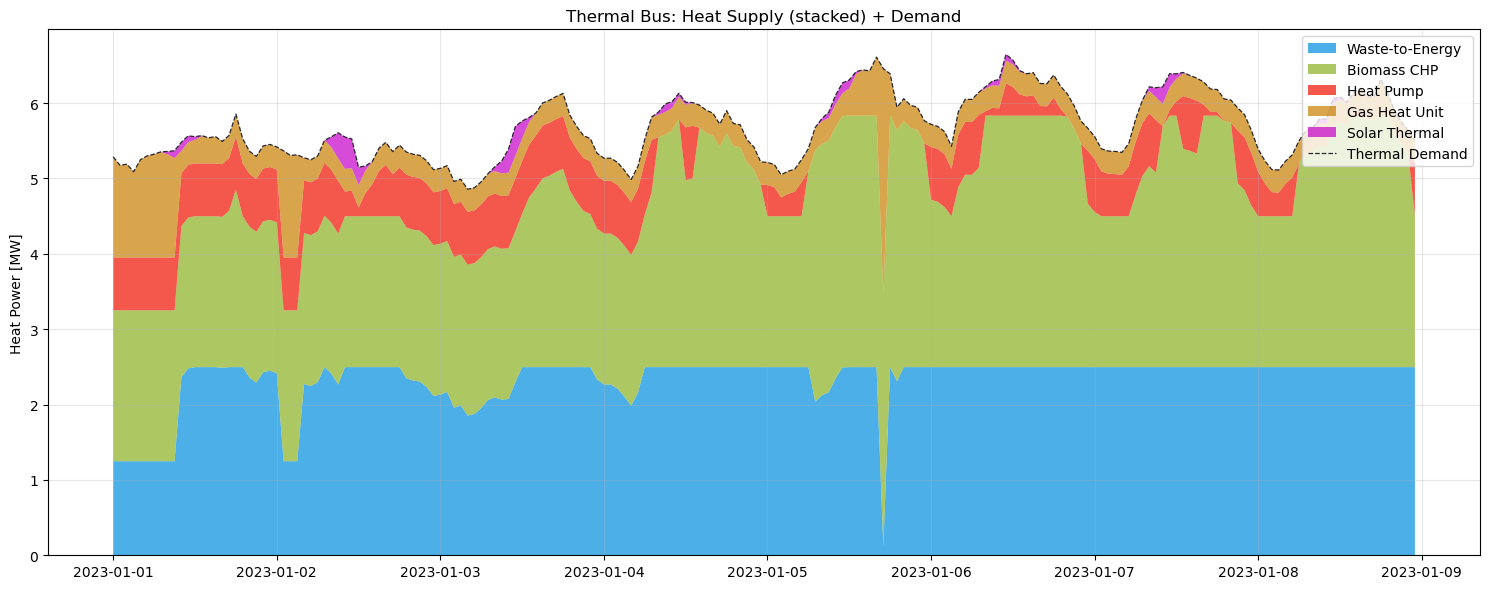

C:\Users\ardia\AppData\Local\Temp\ipykernel_11228\460811449.py:104: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  time_index = pd.date_range(start=start_time, periods=len(df), freq=freq)


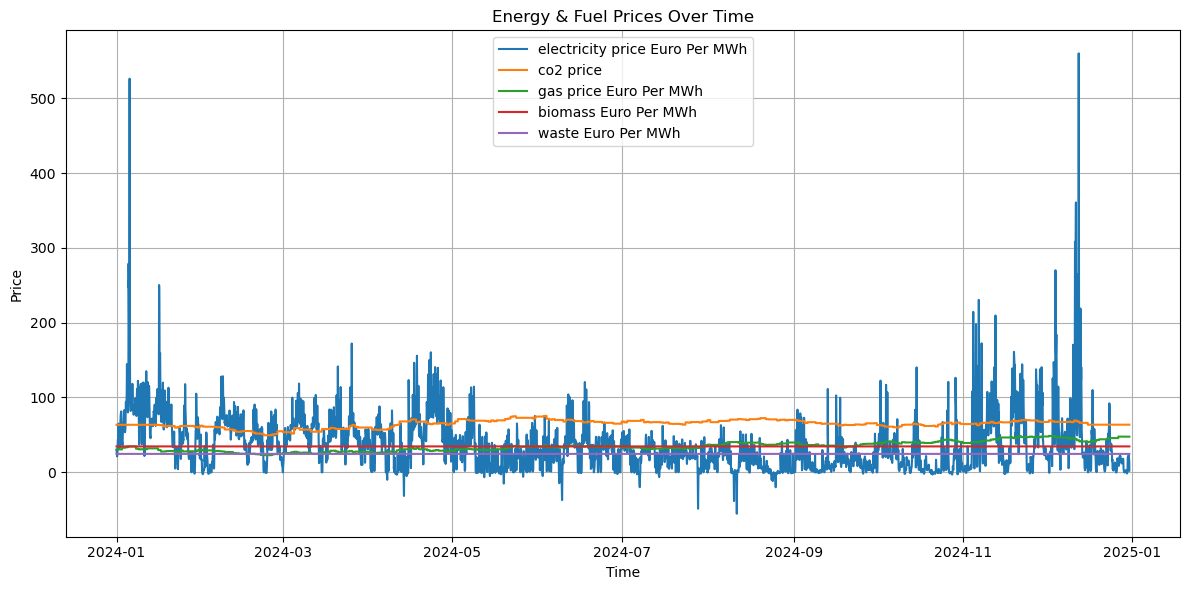

In [16]:
import matplotlib.pyplot as plt
from oemof.solph import views



thermal_bus_view = views.node(results, "thermal_bus")
seq = thermal_bus_view["sequences"].iloc[:-1]  

start = "2023-01-01"
end   = "2023-01-08"

seq = seq.loc[start:end]

# Column names from your results
col_wte       = (("waste_to_energy", "thermal_bus"), "flow")
col_biomass   = (("chp_biomass", "thermal_bus"), "flow")
col_gas       = (("heat_gas", "thermal_bus"), "flow")
col_hp        = (("heat_pump", "thermal_bus"), "flow")
col_solar_th  = (("solar_thermal", "thermal_bus"), "flow")  

has_hp = col_hp in seq.columns
has_solar_th = col_solar_th in seq.columns

# Desired order from BOTTOM (first) → TOP (last)
stack_order = [
    "wte",   
    "biomass",
    "hp", 

    "gas",    "solar_th",

]
components = {
    "biomass": {
        "series": seq[col_biomass],
        "label": "Biomass CHP",
        "color": "#8AB020",
    },
    "gas": {
        "series": seq[col_gas],
        "label": "Gas Heat Unit",
        "color": "#C87E00",
    },
    "wte": {
        "series": seq[col_wte],
        "label": "Waste-to-Energy",
        "color": "#008DDF",
    },
    "hp": {
        "series": seq[col_hp] if has_hp else None,
        "label": "Heat Pump",
        "color": "#F01000",
    },
    "solar_th": {
        "series": seq[col_solar_th] if has_solar_th else None,
        "label": "Solar Thermal",
        "color": "#C500C8",
    },
}
supply_components = []
labels = []
colors = []

for key in stack_order:
    c = components[key]
    if c["series"] is not None:
        supply_components.append(c["series"])
        labels.append(c["label"])
        colors.append(c["color"])
plt.figure(figsize=(15, 6))

plt.stackplot(
    seq.index,
    *supply_components,
    labels=labels,
    colors=colors,
    alpha=0.7,
)

plt.plot(
    seq.index,
    seq[(("thermal_bus","thermal_demand"), "flow")],
    label="Thermal Demand",
    color="#262630",
    linestyle="--",
    linewidth=0.9,
)

plt.title("Thermal Bus: Heat Supply (stacked) + Demand")
plt.ylabel("Heat Power [MW]")
plt.grid(True, alpha=0.3)
plt.legend(loc="upper right")
plt.tight_layout()
plt.show()



import pandas as pd
import matplotlib.pyplot as plt

def load_data(csv_path, start_time="2024-01-01 00:00", freq="H"):
    """Load CSV and generate datetime index."""
    df = pd.read_csv(csv_path)
    time_index = pd.date_range(start=start_time, periods=len(df), freq=freq)
    df.insert(0, "time", time_index)
    df.set_index("time", inplace=True)
    return df


def select_range(df, start=None, end=None):
    """Select a time-window."""
    if start is not None:
        df = df.loc[start:]
    if end is not None:
        df = df.loc[:end]
    return df


def plot_prices(df):
    """Plot only price-related variables in one figure."""
    price_cols = [
        "electricity_price_Euro_Per_MWh",
        "co2_price",
        "gas_price_Euro_Per_MWh",
        "biomass_Euro_Per_MWh",
        "waste_Euro_Per_MWh"
    ]

    plt.figure(figsize=(12, 6))

    for col in price_cols:
        plt.plot(df.index, df[col], label=col.replace("_", " "))

    plt.xlabel("Time")
    plt.ylabel("Price")
    plt.title("Energy & Fuel Prices Over Time")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    # 1) Load your CSV
    csv_file = "OEMOF_files/input_data.csv"
    df_full = load_data(csv_file)

    # 2) Select a range if needed
    df_slice = select_range(df_full,
                            start="2024-01-01",
                            end="2024-12-31")

    # 3) Plot all prices together
    plot_prices(df_slice)
